## 1 — Imports and dataset

In [26]:
import numpy as np
import pandas as pd
import random

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

seed = 42
np.random.seed(seed)
random.seed(seed)

In [27]:
df = pd.read_csv('HR_data.csv', index_col=0)

print('Shape:', df.shape)
print('Subjects :', df['Individual'].nunique())
print('Cohorts  :', df['Cohort'].nunique())
print('Rows per subject:', df['Individual'].value_counts().unique())

assert df['Individual'].nunique() == 14
assert (df['Individual'].value_counts() == 12).all()
df.head()

Shape: (168, 12)
Subjects : 14
Cohorts  : 2
Rows per subject: [12]


,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC,Round,Phase,Individual,Puzzler,Frustrated,Cohort
0,77.965186,78.00,3.345290,73.23,83.37,22924.945,round_3,phase3,1,1,1,D1_1
1,70.981097,70.57,2.517879,67.12,78.22,21930.400,round_3,phase2,1,1,5,D1_1
2,73.371959,73.36,3.259569,67.88,80.22,21647.085,round_3,phase1,1,1,0,D1_1
3,78.916822,77.88,4.054595,72.32,84.92,25258.905,round_2,phase3,1,1,1,D1_1
4,77.322226,74.55,6.047603,70.52,90.15,23890.565,round_2,phase2,1,1,5,D1_1


### Features, target and grouping variable

In [28]:
feature_cols = ['HR_Mean', 'HR_Median', 'HR_std', 'HR_Min', 'HR_Max', 'HR_AUC']

FRUST_THRESHOLD = 2
X = df[feature_cols].copy()
y = (df['Frustrated'] >= FRUST_THRESHOLD).astype(int).to_numpy()
groups = df['Individual'].to_numpy()

N, M = X.shape
print(f'Number of input features: {M}')
print(f'Class balance (y=1 frustrated): {y.mean()*100:.0f}% positive '
      f'({y.sum()} vs {len(y)-y.sum()})')

Number of input features: 6
Class balance (y=1 frustrated): 56% positive (94 vs 74)


In [29]:
per_subject = df.assign(y=y).groupby('Individual')['y'].mean().round(2)
print('Fraction of "frustrated" rows per subject:')
print(per_subject.to_string())

Fraction of "frustrated" rows per subject:
Individual
1     0.33
2     0.58
3     0.75
4     0.92
5     0.75
6     0.75
7     1.00
8     0.75
9     0.58
10    0.17
11    0.42
12    0.25
13    0.17
14    0.42


## 2 — Exploratory data analysis
### Correlation matrix — HR features and frustration

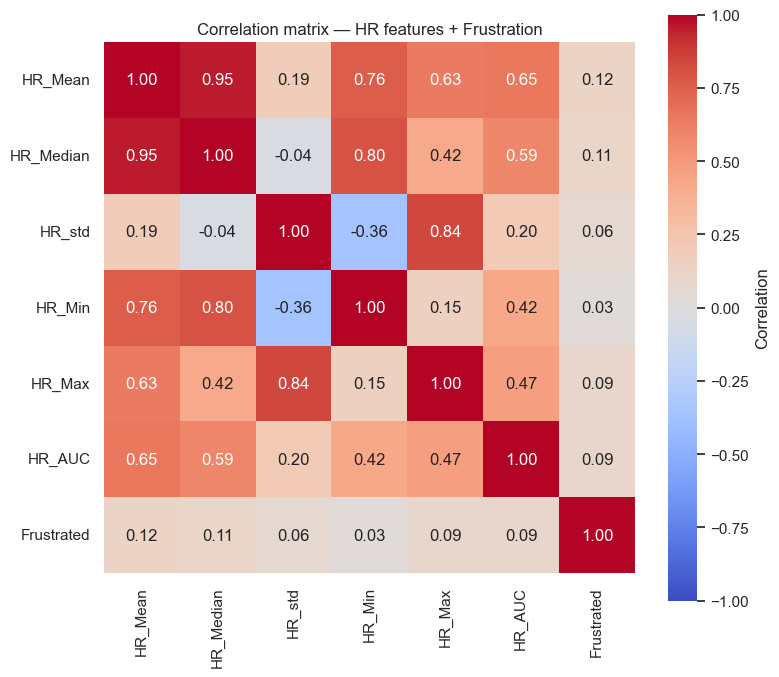

In [30]:
corr_cols = feature_cols + ['Frustrated']
corr = np.corrcoef(df[corr_cols].astype(float).values.T)

plt.figure(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True,
            xticklabels=corr_cols, yticklabels=corr_cols,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation matrix — HR features + Frustration')
plt.tight_layout()
plt.show()

### PCA

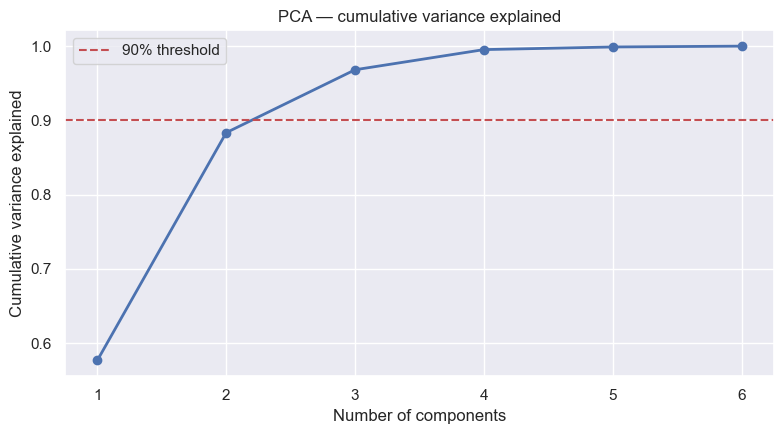

Components for 90% variance: 3


In [31]:
def compute_pca(X, n_components=2):
    X_mean = np.mean(X, axis=0)
    U, s, Vt = np.linalg.svd(X - X_mean, full_matrices=False)
    return Vt.T[:, :n_components], X_mean

X_std_all = (X.values - X.values.mean(0)) / X.values.std(0)
U, s, Vt = np.linalg.svd(X_std_all - X_std_all.mean(0), full_matrices=False)
rhos = s**2 / np.sum(s**2)
cum = np.cumsum(rhos)

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(cum) + 1), cum, 'o-', linewidth=2, markersize=6)
plt.axhline(0.9, color='r', linestyle='--', label='90% threshold')
plt.xlabel('Number of components')
plt.ylabel('Cumulative variance explained')
plt.title('PCA — cumulative variance explained')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Components for 90% variance: {np.argmax(cum >= 0.90) + 1}')

## 3 — The two models

| Model | Type | Why |
|---|---|---|
| **Logistic regression** | linear, high-bias / low-variance | natural baseline for 168 rows |
| **Random forest** | non-linear ensemble | contrast for robustness / consistency |

In [32]:
def standardize_train_test(X_train, X_test):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1.0
    return (X_train - mean) / std, (X_test - mean) / std


def make_models():
    return {
        'LogReg':       LogisticRegression(max_iter=1000, random_state=seed),
        'RandomForest': RandomForestClassifier(n_estimators=300, random_state=seed),
    }

make_models()

{'LogReg': LogisticRegression(max_iter=1000, random_state=42),
 'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42)}

## 4 — The cross-validation scheme

In [33]:
def run_cv(cv, X, y, groups, use_groups, verbose=False):
    names = list(make_models().keys())
    ba  = {m: [] for m in names}
    acc = {m: [] for m in names}
    f1  = {m: [] for m in names}
    tr_acc = {m: [] for m in names}
    pooled = {m: np.zeros(len(y), dtype=int) for m in names}

    splitter = cv.split(X, y, groups) if use_groups else cv.split(X, y)
    for fold, (train_index, test_index) in enumerate(splitter):
        X_train = X.iloc[train_index, :].to_numpy()
        X_test  = X.iloc[test_index, :].to_numpy()
        y_train, y_test = y[train_index], y[test_index]

        X_train, X_test = standardize_train_test(X_train, X_test)

        line = ''
        for name, model in make_models().items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            ba[name].append(balanced_accuracy_score(y_test, y_pred))
            acc[name].append(accuracy_score(y_test, y_pred))
            f1[name].append(f1_score(y_test, y_pred, average='macro'))
            tr_acc[name].append(model.score(X_train, y_train))
            pooled[name][test_index] = y_pred
            line += f'{name}={acc[name][-1]:.3f}  '

        if verbose:
            sid = groups[test_index[0]]
            print(f'Subject {sid:>2}: {line}')

    return ba, acc, f1, tr_acc, pooled

In [34]:
cv_naive = StratifiedKFold(n_splits=14, shuffle=True, random_state=seed)
naive_ba, naive_acc, naive_f1, naive_tr, naive_pred = run_cv(
    cv_naive, X, y, groups, use_groups=False)

print('LOSO (per held-out subject, raw test accuracy):')
cv_loso = LeaveOneGroupOut()
loso_ba, loso_acc, loso_f1, loso_tr, loso_pred = run_cv(
    cv_loso, X, y, groups, use_groups=True, verbose=True)

LOSO (per held-out subject, raw test accuracy):
Subject  1: LogReg=0.250  RandomForest=0.500  
Subject  2: LogReg=0.583  RandomForest=0.667  
Subject  3: LogReg=0.500  RandomForest=0.750  
Subject  4: LogReg=0.583  RandomForest=0.583  
Subject  5: LogReg=0.750  RandomForest=0.583  
Subject  6: LogReg=0.417  RandomForest=0.667  


/Users/bertramsillesen/miniforge3/envs/dtu02451/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/bertramsillesen/miniforge3/envs/dtu02451/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Subject  7: LogReg=0.417  RandomForest=0.333  
Subject  8: LogReg=0.833  RandomForest=0.500  
Subject  9: LogReg=0.583  RandomForest=0.500  
Subject 10: LogReg=0.417  RandomForest=0.667  
Subject 11: LogReg=0.583  RandomForest=0.667  
Subject 12: LogReg=0.500  RandomForest=0.500  
Subject 13: LogReg=0.167  RandomForest=0.167  
Subject 14: LogReg=0.417  RandomForest=0.667  


### Results table — model × scheme × metric (mean ± std across folds)

In [35]:
def summarise(d):
    return {m: (np.mean(v), np.std(v)) for m, v in d.items()}

rows = []
for scheme, acc, ba, f1d in [('Naive k-fold', naive_acc, naive_ba, naive_f1),
                             ('LOSO',         loso_acc,  loso_ba,  loso_f1)]:
    sacc, sba, sf1 = summarise(acc), summarise(ba), summarise(f1d)
    for m in make_models():
        rows.append({'Scheme': scheme, 'Model': m,
                     'Accuracy':      f'{sacc[m][0]:.3f} ± {sacc[m][1]:.3f}',
                     'Balanced acc.': f'{sba[m][0]:.3f} ± {sba[m][1]:.3f}',
                     'Macro-F1':      f'{sf1[m][0]:.3f} ± {sf1[m][1]:.3f}'})
results = pd.DataFrame(rows)
display(results)

,Scheme,Model,Accuracy,Balanced acc.,Macro-F1
0,Naive k-fold,LogReg,0.589 ± 0.116,0.573 ± 0.123,0.561 ± 0.123
1,Naive k-fold,RandomForest,0.565 ± 0.123,0.548 ± 0.131,0.528 ± 0.144
2,LOSO,LogReg,0.500 ± 0.170,0.520 ± 0.151,0.447 ± 0.172
3,LOSO,RandomForest,0.554 ± 0.150,0.551 ± 0.136,0.487 ± 0.152


### Optimism-gap figure — naive k-fold vs LOSO (the "money" figure)

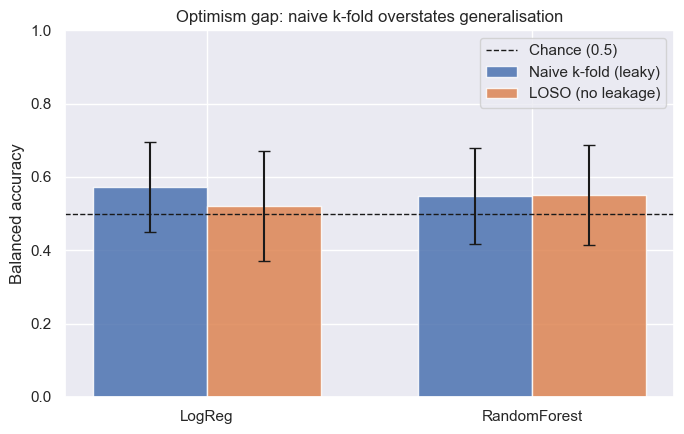

      LogReg: naive 0.573 - LOSO 0.520 = gap +0.052
RandomForest: naive 0.548 - LOSO 0.551 = gap -0.003


In [36]:
names = list(make_models().keys())
x_pos = np.arange(len(names))
width = 0.35
nv_m = [np.mean(naive_ba[m]) for m in names]; nv_s = [np.std(naive_ba[m]) for m in names]
lo_m = [np.mean(loso_ba[m])  for m in names]; lo_s = [np.std(loso_ba[m])  for m in names]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x_pos - width/2, nv_m, width, yerr=nv_s, capsize=4, alpha=0.85, label='Naive k-fold (leaky)')
ax.bar(x_pos + width/2, lo_m, width, yerr=lo_s, capsize=4, alpha=0.85, label='LOSO (no leakage)')
ax.axhline(0.5, color='k', linewidth=1, linestyle='--', label='Chance (0.5)')
ax.set_xticks(x_pos); ax.set_xticklabels(names)
ax.set_ylabel('Balanced accuracy'); ax.set_ylim(0, 1)
ax.set_title('Optimism gap: naive k-fold overstates generalisation')
ax.legend(); plt.tight_layout()
plt.show()

for m in names:
    print(f'{m:>12}: naive {np.mean(naive_ba[m]):.3f} - LOSO {np.mean(loso_ba[m]):.3f} '
          f'= gap {np.mean(naive_ba[m]) - np.mean(loso_ba[m]):+.3f}')

### Per-subject train-vs-test accuracy (LOSO)

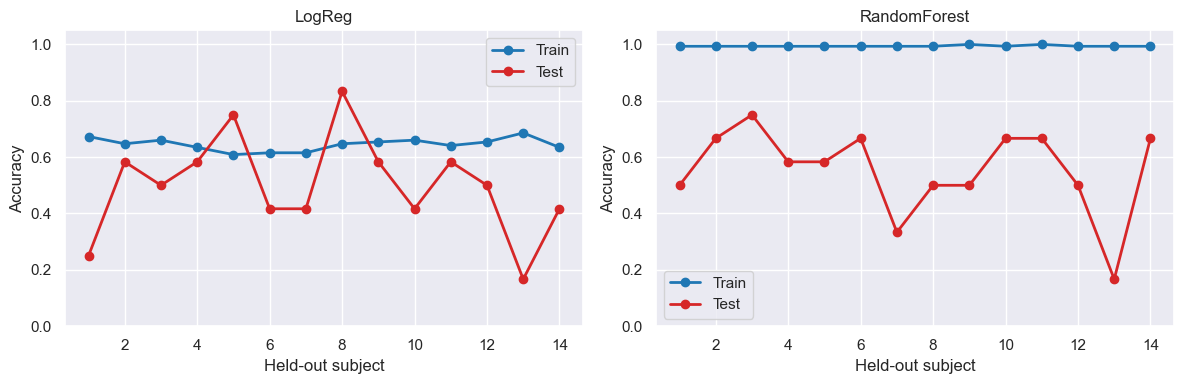

In [37]:
subjects = np.arange(1, len(loso_acc['LogReg']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, m in zip(axes, names):
    ax.plot(subjects, loso_tr[m],  'o-', color='tab:blue', linewidth=2, label='Train')
    ax.plot(subjects, loso_acc[m], 'o-', color='tab:red',  linewidth=2, label='Test')
    ax.set_xlabel('Held-out subject'); ax.set_ylabel('Accuracy')
    ax.set_title(m); ax.set_ylim(0, 1.05); ax.legend()
plt.tight_layout()
plt.show()

## 5 — Statistical measures

In [38]:
def correlated_ttest(r, rho, alpha=0.05):
    r = np.array(r)
    r_hat = np.mean(r); s_hat = np.std(r, ddof=1); J = len(r)
    sigma_tilde = s_hat * np.sqrt((1 / J) + (rho / (1 - rho)))
    CI = st.t.interval(1 - alpha, df=J - 1, loc=r_hat, scale=sigma_tilde)
    p = 2 * st.t.cdf(-np.abs(r_hat) / sigma_tilde, df=J - 1)
    return r_hat, CI, p


def mcnemar(y_true, yhatA, yhatB, alpha=0.05):
    y_true, yhatA, yhatB = map(np.asarray, (y_true, yhatA, yhatB))
    nn = np.zeros((2, 2))
    cA = yhatA == y_true; cB = yhatB == y_true
    nn[0, 0] = np.sum(cA & cB);  nn[0, 1] = np.sum(cA & ~cB)
    nn[1, 0] = np.sum(~cA & cB); nn[1, 1] = np.sum(~cA & ~cB)
    n = nn.sum(); n12, n21 = nn[0, 1], nn[1, 0]
    thetahat = (n12 - n21) / n
    Q = (n**2 * (n + 1) * (thetahat + 1) * (1 - thetahat)
         / (n * (n12 + n21) - (n12 - n21) ** 2))
    p = (thetahat + 1) * 0.5 * (Q - 1); q = (1 - thetahat) * 0.5 * (Q - 1)
    CI = tuple(2 * b - 1 for b in st.beta.interval(1 - alpha, a=p, b=q))
    p_value = 2 * st.binom.cdf(min(n12, n21), n=int(n12 + n21), p=0.5)
    return thetahat, CI, p_value

### Q-Q normality check on the per-fold differences

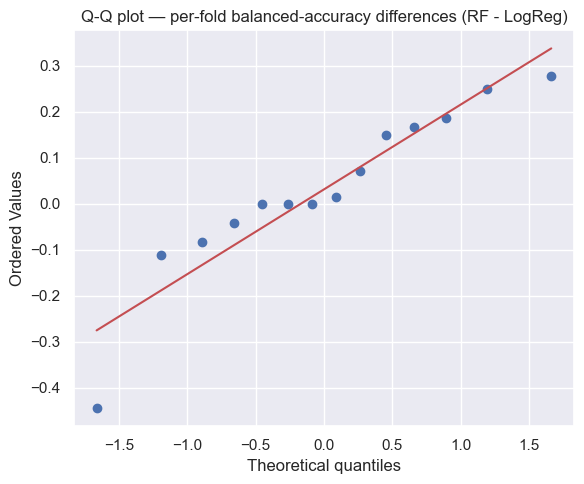

In [39]:
diff = np.array(loso_ba['RandomForest']) - np.array(loso_ba['LogReg'])
plt.figure(figsize=(6, 5))
st.probplot(diff, dist='norm', plot=plt)
plt.title('Q-Q plot — per-fold balanced-accuracy differences (RF - LogReg)')
plt.tight_layout()
plt.show()

In [40]:
J = len(loso_ba['LogReg']); rho = 1.0 / J
r = np.array(loso_ba['LogReg']) - np.array(loso_ba['RandomForest'])

# (a) Correlated t-test
r_hat, CI, p_corr = correlated_ttest(r, rho, alpha=0.05)
print('(a) Correlated t-test (LogReg - RF), J =', J)
print(f'    mean diff = {r_hat:+.3f}  95% CI [{CI[0]:+.3f}, {CI[1]:+.3f}]  p = {p_corr:.3f}')

# (b) McNemar on pooled LOSO predictions
theta, CIm, p_mc = mcnemar(y, loso_pred['LogReg'], loso_pred['RandomForest'])
print('\n(b) McNemar (pooled LOSO predictions)')
print(f'    theta = {theta:+.3f}  95% CI [{CIm[0]:+.3f}, {CIm[1]:+.3f}]  p = {p_mc:.3f}')

# (c) Wilcoxon signed-rank
w_stat, p_w = st.wilcoxon(loso_ba['LogReg'], loso_ba['RandomForest'], zero_method='zsplit')
print('\n(c) Wilcoxon signed-rank (per-fold balanced accuracy)')
print(f'    statistic = {w_stat:.1f}  p = {p_w:.3f}')

# (d) Plain paired t-test + 95% CI (the friend's approach)
t_stat, p_t = st.ttest_rel(loso_ba['LogReg'], loso_ba['RandomForest'])
md_ = np.mean(r); ci = 1.96 * np.std(r, ddof=1) / np.sqrt(J)
print('\n(d) Paired t-test (LogReg - RF), naive (independence assumed)')
print(f'    t = {t_stat:+.3f}  p = {p_t:.3f}  mean diff {md_:+.3f}  95% CI [{md_-ci:+.3f}, {md_+ci:+.3f}]')

(a) Correlated t-test (LogReg - RF), J = 14
    mean diff = -0.031  95% CI [-0.183, +0.121]  p = 0.667

(b) McNemar (pooled LOSO predictions)
    theta = -0.054  95% CI [-0.139, +0.032]  p = 0.281

(c) Wilcoxon signed-rank (per-fold balanced accuracy)
    statistic = 37.0  p = 0.330

(d) Paired t-test (LogReg - RF), naive (independence assumed)
    t = -0.634  p = 0.537  mean diff -0.031  95% CI [-0.127, +0.065]


## 6 — Decision boundaries in PCA space

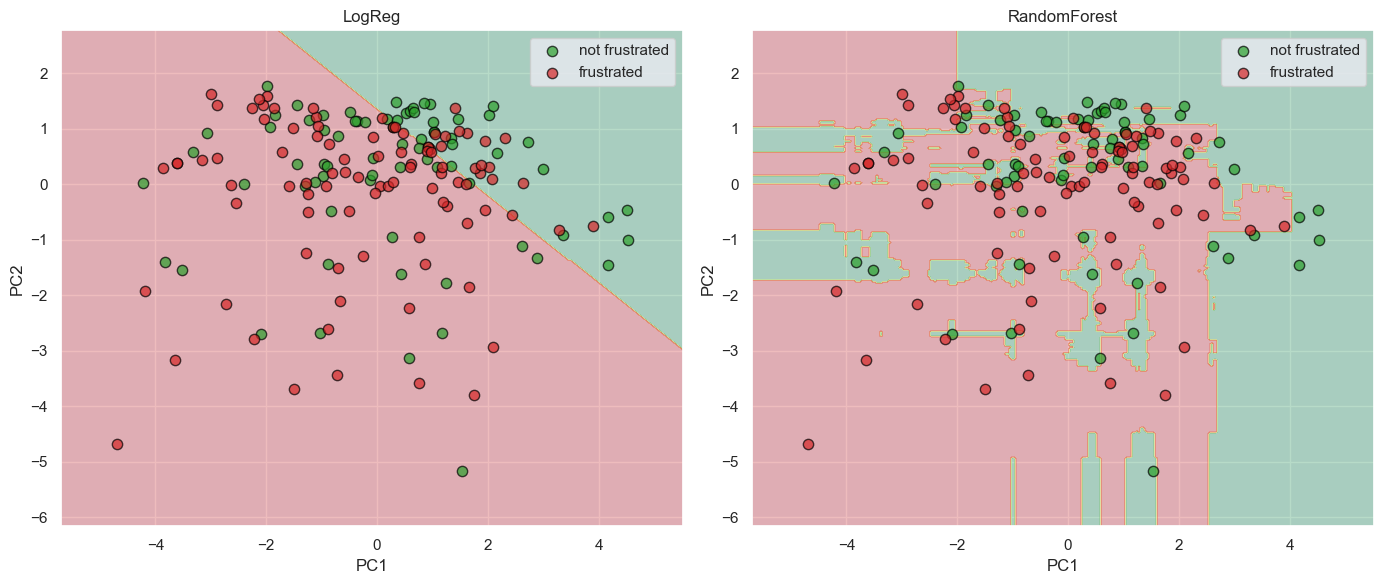

In [41]:
# Standardize all rows, then project to 2 PCs (visualisation only)
X_std_all = (X.values - X.values.mean(0)) / X.values.std(0)
V_k, pca_mean = compute_pca(X_std_all, n_components=2)
X_pca = (X_std_all - pca_mean) @ V_k

viz_models = {'LogReg': LogisticRegression(max_iter=1000, random_state=seed),
              'RandomForest': RandomForestClassifier(n_estimators=300, random_state=seed)}
for m in viz_models.values():
    m.fit(X_pca, y)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

class_names = {0: 'not frustrated', 1: 'frustrated'}
class_cols = {0: 'tab:green', 1: 'tab:red'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, model) in zip(axes, viz_models.items()):
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn_r')
    for cv_ in np.unique(y):
        mask = y == cv_
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], color=class_cols[cv_],
                   label=class_names[cv_], s=55, alpha=0.7, edgecolors='black')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title(name); ax.legend()
plt.tight_layout()
plt.show()